# MNIST 손글씨 숫자 다중 클래스 분류
- 0 ~ 9 손글씨 이미지 (해상도 28x28)

### 학습 목표
- CNN 기반 이미지 분류 모델
- train / valid / test 데이터 분리
- 데이터 정규화 및 데이터 증강
- DataLoader를 활용하여 미니배치 학습
- CrossEntropyLoss 손실함수
- AdamW 최적화함수 (Adam + Weight Decay)
- Scheduler (학습 상황에 따라 learning rate 조정)
- BatchNorm (학습 안정화, 학습 수렴 지원), Dropout(일부 랜덤 뉴런 비활성화, 과적합 방지), weight Decay (특정 가중치가 너무 커지는 것을 방지해주는 장치, 과적합 방지)
- Gradient Clipping ( 기울기가 너무 커지는 문제 완화)
- EarlyStopping (일정 학습기간동안 성능 개선 없을시 조기종료)
- 시각화
- Confusion Matrix 등 지표
- 오분류 이미지 확인

기본 정보
- 문제 유형 : 다중 클래스 분류
- 입력 데이터 : 28 x 28 흑백 손글씨 이미지
- 출력 데이터 : 숫자 클래스 0~9

1. 라이브러리 불러오기

In [1]:
import random # 시드 고정
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn # 신경망 구성
import torch.optim as optim # 최적화 함수
from torch.utils.data import DataLoader, Subset # 미니배치 / 데이터 분리

from torchvision import datasets, transforms # 이미지 데이터셋/ 이미지 전처리 도구

from tqdm.auto import tqdm # 진행바

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

2. 랜덤 시드 고정

In [2]:
SEED = 42

random.seed(SEED)                                # Python random 시드 고정
np.random.seed(SEED)                             # Numpy 시드 고정
torch.manual_seed(SEED)                          # Pytorch CPU 시드 고정
torch.cuda.manual_seed_all(SEED)                 # Pytorch GPU 시드 고정

device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')  # GPU 사용가능시 GPU 사용(cuda), 아니면 CPU 사용(cpu) 
device

device(type='cpu')

3. MNIST 데이터 불러오기

In [3]:
# MNIST에서 주로 전처리시에 사용하는 평균과 표준편차
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081


# 학습 데이터 전처리 도구: 데이터 증강 + Tensor 변환 + 정규화
train_transform = transforms.Compose([
    transforms.RandomRotation(10),                      # 이미지를 -10 ~ 10도 범위로 랜덤 회전
    transforms.ToTensor(),                              # 이미지 내부값을 Tensor로 변환 (0~1 범위로 MinMax Scailing)
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,))   # 평균과 표준편차를 이용해 정규화
])

# 검증/ 테스트 데이터 전처리 도구: Tensor 변환 + 정규화 (검증 / 테스트 시에는 증강 전처리는 사용안함)
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,))
])

# 학습용 MNIST 데이터셋 (증강 적용)
full_train_dataset_aug = datasets.MNIST(
    root = './data',             # 저장 경로
    train = True,                # 학습 / 테스트 데이터셋 중 학습 데이터셋
    download = True,             # 데이터 없으면 다운로드
    transform = train_transform  # 전처리 적용
)

# 검증용으로 사용할 학습 데이터셋 (증강 미적용)
full_train_dataset_eval = datasets.MNIST(
    root = './data',
    train = True,
    download = True,
    transform = eval_transform
)

# 최종 평가용 테스트 데이터셋 (증강 미적용)
test_dataset = datasets.MNIST(
    root = './data',
    train = False,              
    download = True,
    transform = eval_transform
)

print(f"전체 학습 데이터 수 : {len(full_train_dataset_aug)}")
print(f"전체 검증 데이터 수 : {len(full_train_dataset_eval)}")
print(f"테스트 데이터 수 : {len(test_dataset)}")




전체 학습 데이터 수 : 60000
전체 검증 데이터 수 : 60000
테스트 데이터 수 : 10000


In [4]:
full_train_dataset_aug[0] 


(tensor([[[-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.424

4. Train / valid 데이터 분리

In [5]:
valid_size = 10_000
train_size = len(full_train_dataset_aug) - valid_size

generator = torch.Generator().manual_seed(SEED)    # 데이터 분리시 재현성 추가를 위한 generator 객체

# 전체 인덱스 섞어 인덱스 반환(한번 사용한 인덱스는 다시 나오지 않음)
indices = torch.randperm(len(full_train_dataset_aug), generator = generator)

train_indices = indices[:train_size]  # 학습용 인덱스
valid_indices = indices[train_size:]  # 검증용 인덱스

train_dataset = Subset(full_train_dataset_aug, train_indices) # 데이터 분리(데이터, 인덱스). 증강 적용한 학습 데이터셋
valid_dataset = Subset(full_train_dataset_eval, valid_indices) # 증강 없는 검증 데이터셋

print(f"학습 데이터 수 : {len(train_dataset)}, 검증 데이터 수 : {len(valid_dataset)}, 테스트 데이터 수 : {len(test_dataset)}")

학습 데이터 수 : 50000, 검증 데이터 수 : 10000, 테스트 데이터 수 : 10000


5. 클래스 분포 확인

In [6]:
class_names = [str(i) for i in range(10)]

train_labels = full_train_dataset_eval.targets[train_indices].numpy()
valid_labels = full_train_dataset_eval.targets[valid_indices].numpy()
test_labels = test_dataset.targets.numpy()

label_df = pd.DataFrame({
    "train" : pd.Series(train_labels).value_counts().sort_index(),
    "valid" : pd.Series(train_labels).value_counts().sort_index(),
    "test" : pd.Series(train_labels).value_counts().sort_index(),
})

label_df

,train,valid,test
0,4923,4923,4923
1,5613,5613,5613
2,4958,4958,4958
3,5093,5093,5093
4,4863,4863,4863
5,4546,4546,4546
6,4933,4933,4933
7,5204,5204,5204
8,4882,4882,4882
9,4985,4985,4985


In [7]:
# 한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

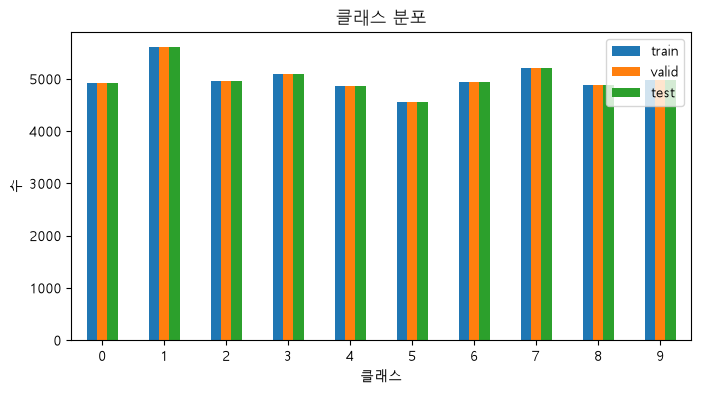

In [8]:
label_df.plot(kind = 'bar', figsize =(8,4))
plt.title("클래스 분포")
plt.xlabel("클래스")
plt.ylabel("수")
plt.xticks(rotation = 0)
plt.show()

6. DataLoader 생성하여 미니배치 학습

In [9]:
BATCH_SIZE = 128             # 이미지 128장씩 사용

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,           # epoch마다 섞음
    num_workers = 0           # 병렬처리 코어 (0은 메인코어)
)
valid_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 0
)

test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 0
)

# 미니배치 하나를 꺼내서 형태 확인
images, labels = next(iter(train_loader))
print(f"images.shape : {images.shape}, labels.shape : {labels.shape}") # (batch_size, channel, height, width), (batch_size)


images.shape : torch.Size([128, 1, 28, 28]), labels.shape : torch.Size([128])


7. 이미지 데이터 확인

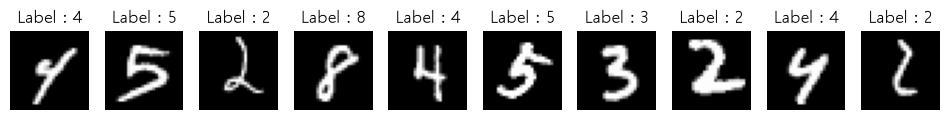

In [10]:
# 역정규화 함수 : 시각화해서 표현하기 위해 원래 범위에
def denormalize(image_tensor):
    return image_tensor * MNIST_STD + MNIST_MEAN

# 이미지 확인 함수
def show_images(dataset, n = 10):
    plt.figure(figsize = (12,2))

    for i in range(n):
        image, label = dataset[i]
        # 흑백 이미지는 차원이 1일 경우 삭제 (컬러 이미지는 삭제하지 않음. imshow[높이, 너비, 채널] 순으로 맞춰 사용.)
        image = denormalize(image).squeeze(0)

        plt.subplot(1,n, i+1)
        plt.imshow(image, cmap = 'gray')
        plt.title(f"Label : {label}")
        plt.axis("off")

    plt.show()

show_images(valid_dataset, 10)            

8. CNN 기반 이미지 분류모델

In [11]:
import torch
import torch.nn as nn

class MNISTCNN(nn.Module):
    def __init__(self, dropout_rate=0.25):
        super().__init__()
        
        # 만약 클래스 내 다른 곳에서도 쓰고 싶다면 아래처럼 self에 저장합니다.
        self.dropout_rate = dropout_rate 

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.SiLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(self.dropout_rate), # self.dropout_rate로 안전하게 참조

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(self.dropout_rate)  # 여기도 동일하게 수정
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MNISTCNN().to(device)
print(model)

MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): SiLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): SiLU()
    (4): Dropout(p=0.4, inplace=False)
    (5): Linear(in_features=128, out_f

9. 손실함수, 최적화함수, Scheduler 설정
- CrossEntropyLoss 손실함수 : 모델 출력값을 내부적으로 확률로 처리하여, 모델의 출력 부분에 softmax를 따로 붙이지 않아도 된다.

In [12]:
# 다중 클래스 분류용 손실하수(5%는 정답 미확신)
criterion = nn.CrossEntropyLoss(label_smoothing = 0.05)

optimizer = optim.AdamW(
    model.parameters(), # 학습할 모델 파라미터
    lr = 0.0001,        # 학습율
    weight_decay = 1e-4 # L2 규제 수치 (과적합 완화)
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = "min",
    factor = 0.5,
    patience = 2
)

10. EarlyStopping 클래스 정의
- 일정 epoch동안 개선이 없으면 학습 조기종료

In [13]:
class EarlyStopping:

    def __init__(self, patience = 4, min_delta = 0.0):
        self.patience = patience        # 개선을 기다릴 epoch
        self.min_delta = min_delta      # 개선으로 인정할 최소 변화량
        self.best_loss = float("inf")   # 최소 
        self.counter = 0
        self.best_state = None

    def __call__(self, valid_loss, model):
        if valid_loss < self.best_loss - self.min_delta:
            self.best_loss = valid_loss
            self.counter = 0
            self.best_state = {
                key : value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            return False

        self.counter += 1
        return self.counter >= self.patience
    
    # 가장 성능이 좋은 모델의 가중치를 모델에 복원

    def restore_best_weights(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)            

11. 학습함수와 평가 함수 정의

In [14]:
# 모델을 1epoch 학습하는 함수
def train_one_epoch(model, dataloader, criterion, optimizer, device, max_norm = 1.0):
    model.train()      # 학습 모드

    total_loss = 0.0  # 전체 손실 (평균 계산)
    total_correct = 0 # 맞춘 갯수 (정확도 계산)
    total_count = 0   # 총 갯수 (평균, 정확도 계산)

    for images, labels in tqdm(dataloader, desc = 'Train', leave = False): # 진행바 남기지않음
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()             # 이전 step 기울기 초기화

        outputs = model(images)           # 예측 logits 반환
        loss = criterion(outputs, labels) # 손실 계산 (내부에서 softmax로 확률 변환)
 
        loss.backward()  # 기울기 계산
        # Gradient Clipping : 특정 기울기 폭주 방지 (규제) -> 과적합 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = max_norm)
        optimizer.step()  # 가중치 업데이트

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size # 배치 전체 loss 누적
        # 클래스별 점수 중 가장 큰 값의 인덱스가 정답이랑 같은 것(예측 성공)의 갯수를 python 수치 형태로 누적
        total_correct += (outputs.argmax(dim = 1) == labels).sum().item()
        total_count += batch_size

    avg_loss = total_loss / total_count    # epoch 전체 평균 손실
    avg_acc = total_correct / total_count  # epoch 전체 정확도
    return avg_loss, avg_acc    

In [15]:
# 평가하는 함수
def evaluate(model, dataloader, criterion, device):
    model.eval()      # 평가 모드(모델 내부 과적합 완화 기법 사용안함)

    total_loss = 0.0  # 전체 손실 (평균 계산)
    total_correct = 0 # 맞춘 갯수 (정확도 계산)
    total_count = 0   # 총 갯수 (평균, 정확도 계산)

    # 평가 중에 기울기 계산 비활성화
    with torch.no_grad(): # 평가 중에 기울기 계산 비활성화
        for images, labels in tqdm(dataloader, desc = 'Evaluate', leave = False): # 진행바 남기지않음
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)           # 예측 logits 반환
            loss = criterion(outputs, labels) # 손실 계산 (내부에서 softmax로 확률 변환)

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size # 배치 전체 loss 누적
            # 클래스별 점수 중 가장 큰 값의 인덱스가 정답이랑 같은 것(예측 성공)의 갯수를 python 수치 형태로 누적
            total_correct += (outputs.argmax(dim = 1) == labels).sum().item()
            total_count += batch_size

    avg_loss = total_loss / total_count    # epoch 전체 평균 손실
    avg_acc = total_correct / total_count  # epoch 전체 정확도
    return avg_loss, avg_acc    

12. 모델 학습

In [16]:
EPOCHS = 10

early_stopping = EarlyStopping(patience = 4, min_delta = 0.0001)
history = []

for epoch in tqdm(range(EPOCHS), desc="Epoch"):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)

    scheduler.step(valid_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch" : epoch + 1,
        "train_loss" : train_loss,
        "train_acc" : train_acc,
        "valid_loss" : valid_loss,
        "valid_acc" : valid_acc,
        "lr" : current_lr
    })

    print(
        f"Epoch: {epoch + 1} | "
        f"Train Loss: {train_loss:.4f} | Train Acc : {train_acc:.4f} | "
        f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f} | "
        f"Learning Rate : {current_lr:.6f}"
    )

    if early_stopping(valid_loss, model):
        print("검증 손실 개선이 이루어지지 않아 EarlyStopping 작동")
        break

early_stopping.restore_best_weights(model)    

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Train:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch: 1 | Train Loss: 1.0236 | Train Acc : 0.7948 | Valid Loss: 0.5874 | Valid Acc: 0.9323 | Learning Rate : 0.000100


Train:   0%|          | 0/391 [00:00<?, ?it/s]

...

Evaluate:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch: 9 | Train Loss: 0.4310 | Train Acc : 0.9683 | Valid Loss: 0.3751 | Valid Acc: 0.9821 | Learning Rate : 0.000100


Train:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch: 10 | Train Loss: 0.4247 | Train Acc : 0.9698 | Valid Loss: 0.3713 | Valid Acc: 0.9832 | Learning Rate : 0.000100


In [23]:
history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,train_acc,valid_loss,valid_acc,lr
0,1,1.023640,0.79482,0.587432,0.93228,0.0001
1,2,0.586517,0.92738,0.455377,0.95778,0.0001
2,3,0.508078,0.94592,0.414842,0.96902,0.0001
3,4,0.477611,0.95362,0.401777,0.97298,0.0001
4,5,0.460895,0.95922,0.391729,0.97680,0.0001
5,6,0.450846,0.96156,0.385605,0.97878,0.0001
6,7,0.441768,0.96502,0.383521,0.97900,0.0001
7,8,0.436608,0.96484,0.377400,0.98080,0.0001
8,9,0.430975,0.96826,0.375054,0.98208,0.0001
9,10,0.424662,0.96982,0.371345,0.98318,0.0001


13. 시각화

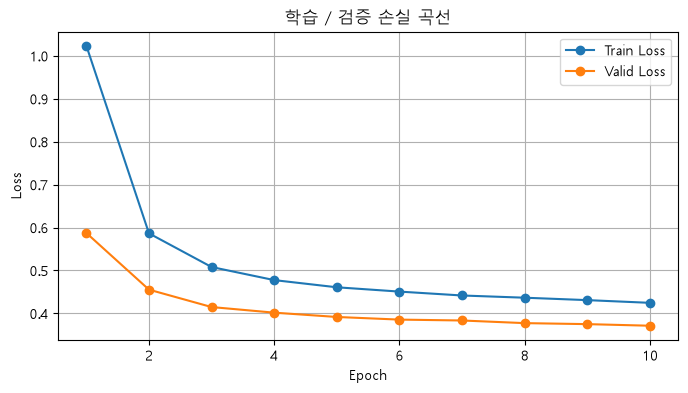

In [24]:
plt.figure(figsize = (8,4))
plt.plot(history_df['epoch'], history_df['train_loss'], marker = 'o', label = 'Train Loss')
plt.plot(history_df['epoch'], history_df['valid_loss'], marker = 'o', label = 'Valid Loss')
plt.title("학습 / 검증 손실 곡선")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


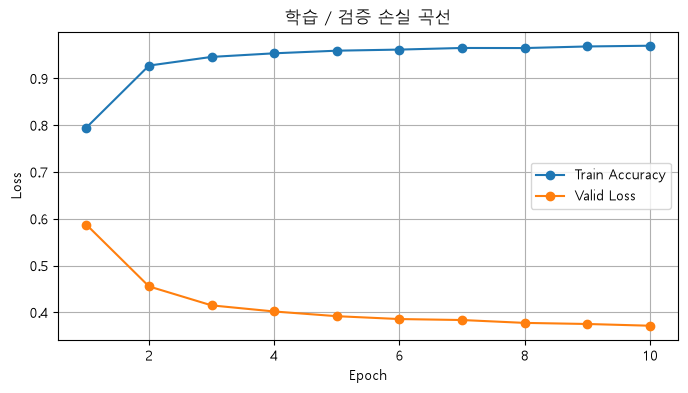

In [25]:
# Train and Validation 정확도 곡선
plt.figure(figsize = (8,4))
plt.plot(history_df['epoch'], history_df['train_acc'], marker = 'o', label = 'Train Accuracy')
plt.plot(history_df['epoch'], history_df['valid_loss'], marker = 'o', label = 'Valid Loss')
plt.title("학습 / 검증 손실 곡선")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

14.Test 데이터로 최종 평가

In [28]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test Loss : {test_loss}, Test Accuracy : {test_acc}")

Evaluate:   0%|          | 0/79 [00:00<?, ?it/s]

Test Loss : 0.3646028391361237, Test Accuracy : 0.9853


15. 예측 결과 수집 & 시각화

In [ ]:
def get_predictions(model, dataloader, device):
    model.eval() # 평가 모드(모델 내부 과적합 완화 기법 사용안함)

    y_true = []  # 실제 정답
    y_pred = []  # 예측 클래스
    y_prob = []  # 예측 확률
 
    with torch.no_grad():  # 평가 중에 기울기 계산 비활성화
        for images, labels in tqdm(dataloader, desc = 'Get Predictions', leave = False): 
            images = images.to(device)

            outputs = model(images) # 예측 logits 반환
            predictions = outputs.argmax(dim = 1) # 가장 높은 점수 클래스를 예측값으로 선택
            probabilities = torch.softmax(outputs, dim = 1) # logits을 클래스별 확률로 변환

            y_true.append(labels.numpy())               # 실제 정답 numpy배열 형태로 저장
            y_pred.append(predictions.cpu().numpy())    # 예측 클래스도 CPU 이동 후 numpy한테 저장
            y_prob.append(probabilities.cpu().numpy())  # 예측 확률도 CPU 이동 후 numpy 형태 저장

    return np.concatenate(y_true), np.concatenate(y_pred), np.concatenate(y_prob) # 배치별 값을 하나의 배열 형태로 합침

y_true, y_pred, y_prob = get_predictions(model, test_loader, device)

print(y_true[:20])
print(y_pred[:20])


Get Predictions:   0%|          | 0/79 [00:00<?, ?it/s]

[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
